In [ ]:
import math

import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib.pyplot as plt 


bond_yields = pd.read_csv("bond_yields.csv")
bond_yields = bond_yields.rename(columns = {"Unnamed: 0" : "date"})
bond_yields['date'] = pd.to_datetime(bond_yields["date"])
bonds_w_date = bond_yields.set_index("date")
bonds_w_date = bonds_w_date.dropna()
bond_ret = bonds_w_date.pct_change().dropna()



Text(0.5, 0, 'time to maturity, years')

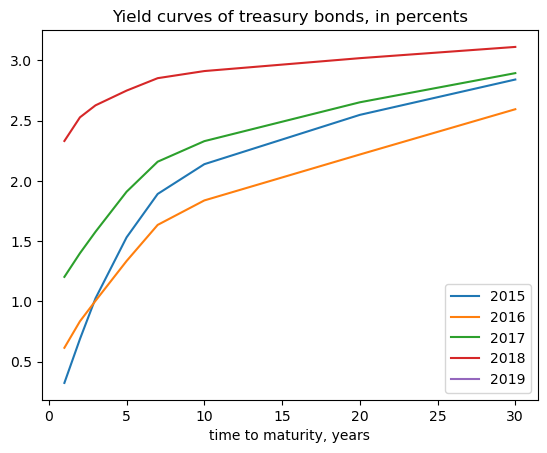

In [207]:
CURVE_KEYS = [1,2,3,5,7,10,20,30]
for year in range(2015, 2020):
    yields = bond_yields[bond_yields['date'].dt.year == year].mean()
    yields = yields.drop("date")
    plt.plot(CURVE_KEYS, yields, label = str(year))
plt.legend()
plt.title("Yield curves of treasury bonds, in percents")
plt.xlabel("time to maturity, years")


In [ ]:
#assumes columns are maturities in years as strings: '1','2','3','5','7','10','20','30'
CURVE_KEYS = [1,2,3,5,7,10,20,30]

# We'll treat the FRED constant-maturity yields as spot (zero) rates (approximation).
# Build a curve dict in *decimals* (e.g., 0.0425 for 4.25%)
def build_curve_from_row(row):
    # row contains y_2, y_5, y_10, y_30 in PERCENT
    return dict(zip(CURVE_KEYS, row/100))

def interp_zero_rate(curve, t_years):
    """
    Piecewise-linear interpolation of zero rate r(t) as a function of maturity t (in years).
    If t < min key, extrapolate flat from first key; same for t > max key.
    """
    ks = np.array(sorted(curve.keys()))
    rs = np.array([curve[k] for k in ks])
    return (np.interp(t_years, ks, rs))



def discount_factor_from_curve(curve, t_years, comp='cont'):
    """
    Discount factor using the interpolated zero rate.
    comp='cont' uses exp(-r t); comp='simple' uses 1/(1+r t) as a sanity alternative.
    """
    r = interp_zero_rate(curve, t_years)
    if comp == 'cont':
        return np.exp(-r * t_years)
    elif comp == 'simple':
        return 1.0 / (1.0 + r * t_years)
    else:
        raise ValueError("comp must be 'cont' or 'simple'")

def bond_cashflows(maturity_years, coupon_rate, freq=2, face=100.0):
    """
    Return a list of (t, cf) for a plain-vanilla fixed coupon bond.
    maturity_years: e.g., 5.0
    coupon_rate: annual coupon in decimals (e.g., 0.03 for 3%)
    freq: payments per year (1, 2, 4). Default 2 = semiannual.
    face: redemption value (usually 100)
    """
    # Payment times in years: 1/f, 2/f, ..., maturity
    n = int(round(maturity_years * freq))
    times = np.arange(1, n + 1, dtype=float) / float(freq)
    # Make sure last time = maturity_years (minor rounding guard)
    times[-1] = maturity_years
    coupon_cf = coupon_rate * face / float(freq)
    cfs = np.full_like(times, coupon_cf, dtype=float)
    cfs[-1] += face
    return list(zip(times, cfs))

# Example
print(bond_cashflows(5.0, 0.03, freq=2)[:4], "... last:", bond_cashflows(5.0, 0.03, freq=2)[-1])

def price_from_curve(curve, maturity_years, coupon_rate, freq=2, face=100.0, comp='cont'):
    cfs = bond_cashflows(maturity_years, coupon_rate, freq=freq, face=face)
    pv = 0.0
    for t, cf in cfs:
        df = discount_factor_from_curve(curve, t, comp=comp)
        pv += cf * df
    return pv

# Quick smoke test
p_5y = price_from_curve(curve, 5.0, 0.03, freq=2, face=100.0)
print("5y 3% bond price (from curve):", round(p_5y, 4))


def price_from_ytm_flat(y, maturity_years, coupon_rate, freq=2, face=100.0):
    """
    Price using a *flat* yield y (decimal) with compounding at 'freq' per year.
    This is the textbook bond pricing under a flat YTM assumption.
    """
    n = int(round(maturity_years * freq))
    c = coupon_rate * face / float(freq)
    df = 1.0 / ((1.0 + y / float(freq)) ** np.arange(1, n+1))
    pv_coupons = c * df.sum()
    pv_redemption = face * df[-1]
    return pv_coupons + pv_redemption



def ytm_from_price(price, maturity_years, coupon_rate, freq=2, face=100.0, guess=0.04):
    """
    Solve for flat YTM y such that price_from_ytm_flat(y) = price.
    Newton-Raphson with a fallback to bisection if needed.
    """
    func = lambda y : price_from_ytm_flat(y, maturity_years, coupon_rate, freq, face) - price 
    ans = scipy.optimize.brentq(func, a = 0, b = .5) #a yield over 50% is insane
    return ans

def risk_parallel(curve, maturity_years, coupon_rate, freq=2, face=100.0, comp='cont', bump_bp=1.0):
    """
    Parallel-bump the entire curve by +/- bump_bp (basis points) and compute:
      - Duration (modified, finite-diff)
      - Convexity (finite-diff)
      - DV01 (dollar value per 1bp)
    Returns: (price0, duration, convexity, dv01)
    """
    bump = bump_bp / 10000.0  # convert bp -> decimal
    price0 = price_from_curve(curve, maturity_years, coupon_rate, freq=freq, face=face, comp=comp)

    # Up/down parallel bumps
    curve_up   = {k: v + bump for k, v in curve.items()}
    curve_down = {k: v - bump for k, v in curve.items()}

    p_up   = price_from_curve(curve_up,   maturity_years, coupon_rate, freq=freq, face=face, comp=comp)
    p_down = price_from_curve(curve_down, maturity_years, coupon_rate, freq=freq, face=face, comp=comp)

    # Modified duration via central difference
    duration = - (p_up - p_down) / (2.0 * bump * price0)

    # Convexity
    convexity = (p_up + p_down - 2.0 * price0) / (price0 * (bump ** 2))

    # DV01 (per 1bp)
    dv01 = - duration * price0 * 1e-4

    return price0, float(duration), float(convexity), float(dv01)

# Example
p0, dur, conv, dv01 = risk_parallel(curve, 5.0, 0.03, freq=2)
print("Parallel risk — P0:", round(p0,4), "Dur:", round(dur,4), "Conv:", round(conv,4), "DV01:", round(dv01,6))
 


[(np.float64(0.5), np.float64(1.5)), (np.float64(1.0), np.float64(1.5)), (np.float64(1.5), np.float64(1.5)), (np.float64(2.0), np.float64(1.5))] ... last: (np.float64(5.0), np.float64(101.5))
5y 3% bond price (from curve): 106.3394
Parallel risk — P0: 106.3394 Dur: 4.6863 Conv: 22.861 DV01: -0.049833


In [80]:
def krdv01s(curve, maturity_years, coupon_rate, freq=2, face=100.0, comp='cont', bump_bp=1.0, keys=(2.0,5.0,10.0,30.0)):
    """
    Key-Rate DV01s: for each specified key maturity, bump ONLY that key by +1bp (others fixed),
    reprice, and compute DV01 at that key = (P_up - P0)/(-1bp)  (negative because price falls when rate rises).
    """
    bump = bump_bp / 10000.0
    P0 = price_from_curve(curve, maturity_years, coupon_rate, freq=freq, face=face, comp=comp)

    out = {}
    for k in keys:
        bumped = dict(curve)
        if k not in bumped:
            # if missing, insert by interpolating the current curve then bump that point
            bumped[k] = interp_zero_rate(curve, k)
        bumped[k] += bump

        P_up = price_from_curve(bumped, maturity_years, coupon_rate, freq=freq, face=face, comp=comp)
        # DV01 at key k: price sensitivity per 1bp at that node
        dv01_k = (P_up - P0) / (-bump_bp)  # per bp
        out[k] = float(dv01_k)
    return out

# Example
kr = krdv01s(curve, 5.0, 0.03, freq=2)
print("Key-Rate DV01s (per bp):", {k: round(v,6) for k,v in kr.items()})
print("Sum of KRDV01s (roughly ≈ parallel DV01):", round(sum(kr.values()), 6))

Key-Rate DV01s (per bp): {2.0: 0.000595, 5.0: 0.047442, 10.0: -0.0, 30.0: -0.0}
Sum of KRDV01s (roughly ≈ parallel DV01): 0.048037


In [222]:
def bond_spec(maturity_years, coupon_rate, freq=2, face=100.0, qty=1.0):
    return {"T": float(maturity_years), "c": float(coupon_rate), "f": int(freq), "F": float(face), "q": float(qty)}

def portfolio_price(curve, bonds, comp='cont'):
    total = 0.0
    for b in bonds:
        p = price_from_curve(curve, b["T"], b["c"], freq=b["f"], face=b["F"], comp=comp)
        total += b["q"] * p
    return total

def portfolio_parallel_risk(curve, bonds, comp='cont', bump_bp=1.0):
    P0 = portfolio_price(curve, bonds, comp=comp)
    bump = bump_bp / 10000.0
    up_curve   = {k: v + bump for k, v in curve.items()}
    down_curve = {k: v - bump for k, v in curve.items()}
    P_up   = portfolio_price(up_curve,   bonds, comp=comp)
    P_down = portfolio_price(down_curve, bonds, comp=comp)

    duration  = - (P_up - P_down) / (2.0 * bump * P0)
    convexity = (P_up + P_down - 2.0 * P0) / (P0 * (bump ** 2))
    dv01      = - duration * P0 * 1e-4
    return P0, float(duration), float(convexity), float(dv01)

def portfolio_krdv01s(curve, bonds, comp='cont', bump_bp=1.0, keys=(2.0,5.0,10.0,30.0)):
    P0 = portfolio_price(curve, bonds, comp=comp)
    out = {}
    for k in keys:
        bumped = dict(curve)
        if k not in bumped:
            bumped[k] = interp_zero_rate(curve, k)
        bumped[k] += bump_bp / 10000.0
        P_up = portfolio_price(bumped, bonds, comp=comp)
        dv01_k = (P_up - P0) / (-bump_bp)
        out[k] = float(dv01_k)
    return out



In [223]:

def portfolio_price(curve, bonds, comp='cont'):
    return float(sum(b["q"]*price_from_curve(curve, b["T"], b["c"], freq=b["f"], face=b["F"], comp=comp) for b in bonds))


def portfolio_parallel_dv01(curve, bonds, comp='cont', bump_bp=1.0):
    P0 = portfolio_price(curve, bonds, comp=comp)
    bump = bump_bp/10000.0
    up   = {k:v+bump for k,v in curve.items()}
    down = {k:v-bump for k,v in curve.items()}
    Pu = portfolio_price(up, bonds, comp=comp); Pd = portfolio_price(down, bonds, comp=comp)
    dur  = - (Pu - Pd)/(2.0*bump*P0)
    dv01 = - dur*P0*1e-4
    return float(dv01)

def bond_metrics(curve, bond, comp='cont', bump_bp=1.0):
    p0, dur, conv, dv01 = risk_parallel(curve, bond["T"], bond["c"],
                                        freq=bond["f"], face=bond["F"],
                                        comp=comp, bump_bp=bump_bp)
    return {"price": p0, "dur": dur, "conv": conv, "dv01": dv01}

def port_metrics(curve, bonds, comp='cont', bump_bp=1.0):
    p0, dur, conv, dv01 = portfolio_parallel_risk(curve, bonds, comp=comp, bump_bp=bump_bp)
    return {"price": p0, "dur": dur, "conv": conv, "dv01": dv01}

def hedge_weights_for_dur_matching(curve, base_bonds, hedge1, hedge2, comp='cont'):
    """Solve for hedge quantities to match base portfolio duration and convexity."""
    base = port_metrics(curve, base_bonds, comp=comp)
    m1 = bond_metrics(curve, hedge1, comp=comp)
    m2 = bond_metrics(curve, hedge2, comp=comp)

    # dollar duration and convexity of base
    B_ddur = base["price"] * base["dur"]

    # each unit of hedge gives:
    h1_ddur = m1["price"] * m1["dur"]
    h2_ddur = m2["price"] * m2["dur"]

    # Solve: q1*h1_ddur + q2*h2_ddur = B_ddur
    # lstsq gives the minimum-norm solution (rank-deficient case)
    A = np.array([[h1_ddur, h2_ddur]], dtype=float)
    b = np.array([B_ddur], dtype=float)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    q1, q2 = sol

    return {"q1": float(q1), "q2": float(q2), "h1": m1, "h2": m2}

def hedge_weights_for_dur_conv_matching(curve, base_bonds, hedge1, hedge2, comp='cont'):
    """Solve for hedge quantities to match base portfolio duration and convexity."""
    base = port_metrics(curve, base_bonds, comp=comp)
    m1 = bond_metrics(curve, hedge1, comp=comp)
    m2 = bond_metrics(curve, hedge2, comp=comp)

    # dollar duration and convexity of base
    B_ddur = base["price"] * base["dur"]
    B_dconv = base["price"] * base["conv"]

    # each unit of hedge gives:
    h1_ddur = m1["price"] * m1["dur"]
    h2_ddur = m2["price"] * m2["dur"]
    h1_dconv = m1["price"] * m1["conv"]
    h2_dconv = m2["price"] * m2["conv"]

    # Solve: q1*h1_ddur + q2*h2_ddur = B_ddur
    #        q1*h1_dconv + q2*h2_dconv = B_dconv
    A = np.array([[h1_ddur, h2_ddur], [h1_dconv, h2_dconv]], dtype=float)
    b = np.array([B_ddur, B_dconv], dtype=float)
    q1, q2 = np.linalg.solve(A, b)

    return {"q1": float(q1), "q2": float(q2), "h1": m1, "h2": m2}

# Config
rebalance_freq = 'M'  # 'M' monthly; use 'W-FRI' for weekly

timeline = bonds_w_date.index
rebal_dates = pd.date_range(timeline.min(), timeline.max(), freq=rebalance_freq)
rebal_dates = [d for d in rebal_dates if d in timeline]
if timeline[-1] not in rebal_dates:
    rebal_dates.append(timeline[-1])

# State: hedge quantities (notional units SHORT)
current_h = {"q1": 0.0, "q2": 0.0}

records = []
prev_prices = None  # {P_port, P_h1, P_h2}

bond1 = bond_spec(2.0, 0.03, freq=2, face=100.0, qty=1.0)   # 2y 3%
bond2 = bond_spec(20.0,0.05, freq=2, face=100.0, qty=1.0)   # 10y 3%

hedge1 = bond_spec(11.0, 0.04, freq = 2, face = 100, qty = 1) #an attempt to duration hedge 
hedge2 = bond_spec(5.0, 0.03, freq = 2, face = 100, qty = 1) #an attempt to convexity hedge 

BONDS = [bond1, bond2]

for b in [bond1, bond2, hedge1, hedge2]:
    p0, dur, conv, dv01 = risk_parallel(curve, b["T"], b["c"], freq=b["f"], face=b["F"])
    print("  Price:", round(p0,4), "Duration:", round(dur,4), "Convexity:", round(conv,2), "DV01:", round(dv01,6))

# Define hedge bonds (define hedge1 and hedge2 if not already done)
# hedge1 = bond_spec(T_years, coupon, freq=2, face=100, qty=1.0)
# hedge2 = bond_spec(T_years, coupon, freq=2, face=100, qty=1.0)

for t in timeline:
    row = bonds_w_date.loc[t]
    curve_t = build_curve_from_row(row)
    
    # Portfolio price at t
    P_port_t = portfolio_price(curve_t, BONDS)
    
    # Hedge bond prices at t
    P_h1_t = price_from_curve(curve_t, hedge1["T"], hedge1["c"], freq=hedge1["f"], face=hedge1["F"])
    P_h2_t = price_from_curve(curve_t, hedge2["T"], hedge2["c"], freq=hedge2["f"], face=hedge2["F"])

    # Rebalance on schedule
    if t in rebal_dates:
        # Solve for hedge weights to match duration and convexity
        w = hedge_weights_for_dur_conv_matching(curve_t, BONDS, hedge1, hedge2)
        current_h = {"q1": w["q1"], "q2": w["q2"]}
        # Optional: print status
        # print(f"{t.date()} rebalanced. q1={w['q1']:.2f}, q2={w['q2']:.2f}")

    # Compute daily P&L (after possible rebalance)
    if prev_prices is None:
        dPnL_port = 0.0
        dPnL_hedge = 0.0
    else:
        dP_port = P_port_t - prev_prices['P_port']
        dP_h1 = P_h1_t - prev_prices['P_h1']
        dP_h2 = P_h2_t - prev_prices['P_h2']
        # Hedge is SHORT, so hedge P&L = -q * ΔPrice
        dPnL_port = dP_port
        dPnL_hedge = -(current_h["q1"] * dP_h1 + current_h["q2"] * dP_h2)

    records.append({
        "date": t, "P_port": P_port_t, "P_h1": P_h1_t, "P_h2": P_h2_t,
        "q1": current_h["q1"], "q2": current_h["q2"],
        "dPnL_port": dPnL_port, "dPnL_hedge": dPnL_hedge,
        "dPnL_combo": dPnL_port + dPnL_hedge
    })

    prev_prices = {"P_port": P_port_t, "P_h1": P_h1_t, "P_h2": P_h2_t}

bt = pd.DataFrame.from_records(records).set_index("date")
bt.to_csv("backtest.csv")
bt.tail()

/var/folders/99/2gc1f4rn5c17rgy65j9f5f5w0000gn/T/ipykernel_27946/2690892023.py:75: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = pd.date_range(timeline.min(), timeline.max(), freq=rebalance_freq)


  Price: 105.2026 Duration: 1.9573 Convexity: 3.88 DV01: -0.020591
  Price: 122.7536 Duration: 13.2646 Convexity: 224.34 DV01: -0.162828
  Price: 110.0896 Duration: 9.0321 Convexity: 92.17 DV01: -0.099434
  Price: 106.3394 Duration: 4.6863 Convexity: 22.86 DV01: -0.049833


,P_port,P_h1,P_h2,q1,q2,dPnL_port,dPnL_hedge,dPnL_combo
date,,,,,,,,
2018-12-24,233.326626,111.746122,101.883085,3.908159,-4.116595,0.942097,-0.825027,0.117070
2018-12-26,232.068164,111.039460,101.466051,3.908159,-4.116595,-1.258462,1.044983,-0.213479
2018-12-27,232.647261,111.453270,101.794021,3.908159,-4.116595,0.579097,-0.267114,0.311983
2018-12-28,233.352858,111.940131,101.985300,3.908159,-4.116595,0.705597,-1.115312,-0.409716
2018-12-31,233.853966,112.250422,102.218876,4.015978,-4.343785,0.501109,-0.231519,0.269590


In [224]:
def ann_vol(x):
    return np.std(x.dropna())*np.sqrt(252)

def max_drawdown(series):
    cum = series.cumsum()
    peak = cum.cummax()
    dd = cum - peak
    return float(dd.min())

def hist_var(x, p=0.95):
    # one-day historical VaR at confidence p (reported as negative loss threshold)
    q = np.quantile(x.dropna(), 1-p)
    return float(q)

summary = pd.Series({
    "AnnVol_port": ann_vol(bt["dPnL_port"]),
    "AnnVol_combo": ann_vol(bt["dPnL_combo"]),
    "VarianceReduction_%": 100*(1 - (np.var(bt["dPnL_combo"].dropna()) / np.var(bt["dPnL_port"].dropna()))),
    "TE_vol": ann_vol(bt["dPnL_combo"] - bt["dPnL_port"]),
    "MaxDD_port": max_drawdown(bt["dPnL_port"]),
    "MaxDD_combo": max_drawdown(bt["dPnL_combo"]),
    "VaR95_port": hist_var(bt["dPnL_port"], 0.95),
    "VaR95_combo": hist_var(bt["dPnL_combo"], 0.95),
    "VaR99_port": hist_var(bt["dPnL_port"], 0.99),
    "VaR99_combo": hist_var(bt["dPnL_combo"], 0.99),
})
print(summary.round(4))

AnnVol_port            13.3890
AnnVol_combo            5.0363
VarianceReduction_%    85.8510
TE_vol                 15.8412
MaxDD_port            -38.7909
MaxDD_combo           -18.7889
VaR95_port             -1.4303
VaR95_combo            -0.4951
VaR99_port             -2.0993
VaR99_combo            -0.7442
dtype: float64


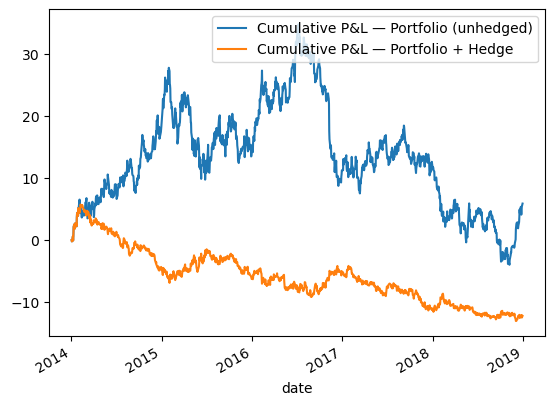

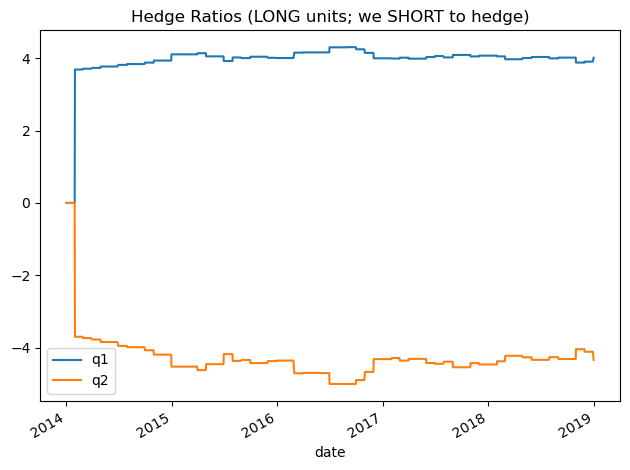

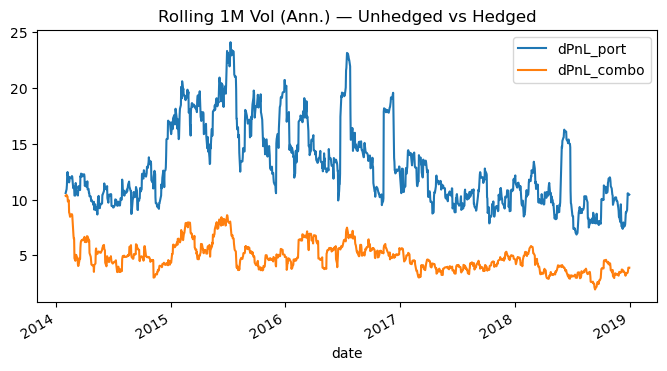

/var/folders/99/2gc1f4rn5c17rgy65j9f5f5w0000gn/T/ipykernel_27946/3940193572.py:15: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  bt[["dPnL_port","dPnL_combo"]].hist(bins=80, ax=ax, alpha=0.6)


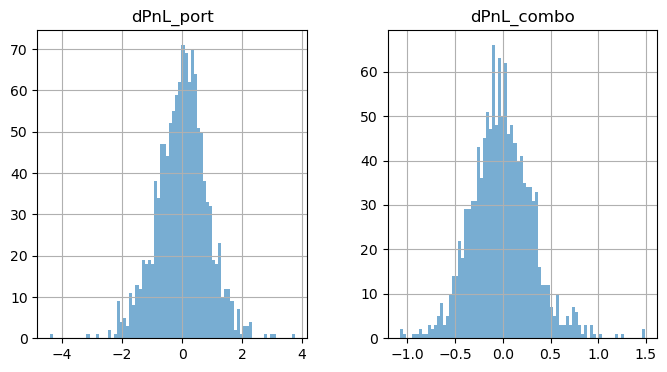

In [225]:
import matplotlib.pyplot as plt 
(bt["dPnL_port"].cumsum()).plot(label="Cumulative P&L — Portfolio (unhedged)")
(bt["dPnL_combo"].cumsum()).plot(label="Cumulative P&L — Portfolio + Hedge")
plt.legend()
plt.show() 

(bt[["q1","q2"]]).plot(title="Hedge Ratios (LONG units; we SHORT to hedge)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1,1, figsize=(8,4))
bt[["dPnL_port","dPnL_combo"]].dropna().rolling(21).std().multiply(np.sqrt(252)).plot(ax=ax)
ax.set_title("Rolling 1M Vol (Ann.) — Unhedged vs Hedged"); plt.show()

fig, ax = plt.subplots(1,1, figsize=(8,4))
bt[["dPnL_port","dPnL_combo"]].hist(bins=80, ax=ax, alpha=0.6)
ax.set_title("One-day P&L Distribution"); plt.show()

# Save figures
plt.figure(figsize=(10,1)); plt.text(0.01,0.5,"(plots above not auto-saved)\nExport as needed", va='center'); plt.axis('off')
plt.savefig("backtest_plots.png", dpi=120, bbox_inches='tight'); plt.close()